In [18]:
import os
import sys
import glob
sys.path.insert(0, "/project/def-nahee/kbas/Graphnet-Applications/Metadata")
import paths
from icecube import icetray

import pandas as pd
from collections import Counter


from icecube import LeptonInjector, simclasses, dataclasses, dataio 


import numpy as np
import matplotlib.pyplot as plt

icetray.I3Logger.global_logger = icetray.I3NullLogger()

In [19]:
DATASET = "SPRING2026MC"

In [20]:
all_datasets = {
    name: val for name, val in vars(paths).items()
    if not name.startswith("_") and isinstance(val, dict)
    and all(isinstance(v, dict) for v in val.values())
}

In [21]:
full_geo = selected_datasets["SPRING2026MC_I3"]["full_geometry"]

def get_event_data(path, fmt):
    data = {k: [] for k in ["energy", "zenith", "azimuth",
                             "bjorken_x", "bjorken_y",
                             "pos_x", "pos_y", "pos_z"]}
    files = sorted(glob.glob(f"{path}/**/*.i3.{fmt}", recursive=True))
    for f in files:
        i3file = dataio.I3File(f)
        for frame in i3file:
            if frame.Stop != icetray.I3Frame.DAQ:
                continue
            try:
                mctree = frame["I3MCTree"]
                primary = mctree.primaries[0]
                ep = frame["EventProperties"]
                data["energy"].append(primary.energy)
                data["zenith"].append(np.degrees(primary.dir.zenith))
                data["azimuth"].append(np.degrees(primary.dir.azimuth))
                data["pos_x"].append(primary.pos.x)
                data["pos_y"].append(primary.pos.y)
                data["pos_z"].append(primary.pos.z)
                data["bjorken_x"].append(ep.finalStateX)
                data["bjorken_y"].append(ep.finalStateY)
            except:
                continue
        i3file.close()
    return {k: np.array(v) for k, v in data.items()}

event_data = {}
for flavor, info in full_geo.items():
    print(f"Reading {flavor}...")
    event_data[flavor] = get_event_data(info["path"], info["format"])
    print(f"  {len(event_data[flavor]['energy'])} events")

# keep energies dict for energy plot cell below
energies = {f: d["energy"] for f, d in event_data.items()}


Reading Muon...
  7444 events
Reading Electron...
  4192 events
Reading Tau...
  5581 events
Reading NC...
  9074 events


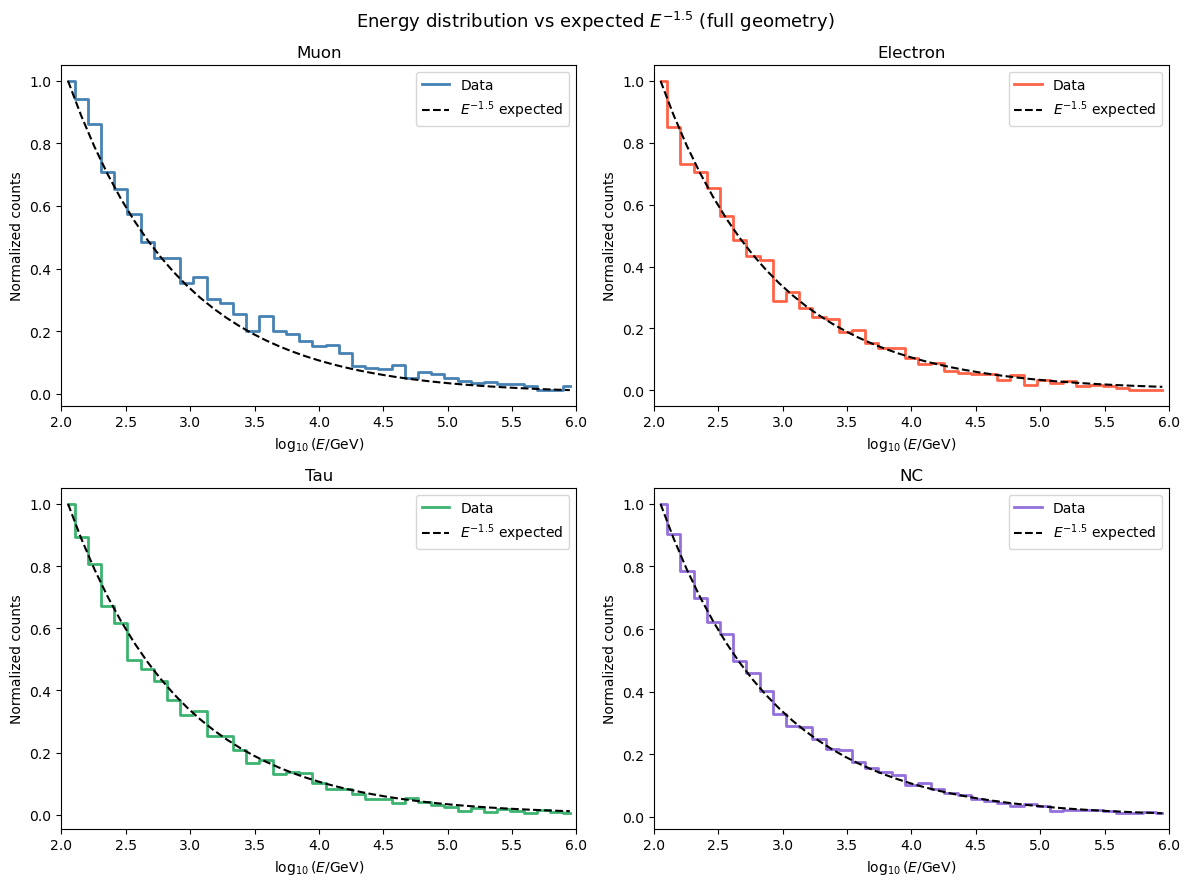

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

colors = {"Muon": "steelblue", "Electron": "tomato", "Tau": "mediumseagreen", "NC": "mediumpurple"}

for ax, (flavor, E) in zip(axes, energies.items()):
    log_E = np.log10(E)
    bins = np.linspace(2, 6, 40)

    counts, edges = np.histogram(log_E, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # normalize to compare shape
    counts_norm = counts / counts.max()

    # expected E^-1.5 shape in log bins: dN/d(logE) ~ E^-1.5 * E * ln(10) ~ E^-0.5
    E_centers = 10**centers
    expected = E_centers**(-0.5)
    expected_norm = expected / expected.max()

    ax.step(centers, counts_norm, where="mid", color=colors[flavor], label="Data", linewidth=2)
    ax.plot(centers, expected_norm, "k--", label=r"$E^{-1.5}$ expected", linewidth=1.5)

    ax.set_xlabel(r"$\log_{10}(E/\mathrm{GeV})$")
    ax.set_ylabel("Normalized counts")
    ax.set_title(flavor)
    ax.legend()
    ax.set_xlim(2, 6)

plt.suptitle("Energy distribution vs expected $E^{-1.5}$ (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig("energy_distribution_full_geometry.png", dpi=150)
plt.show()


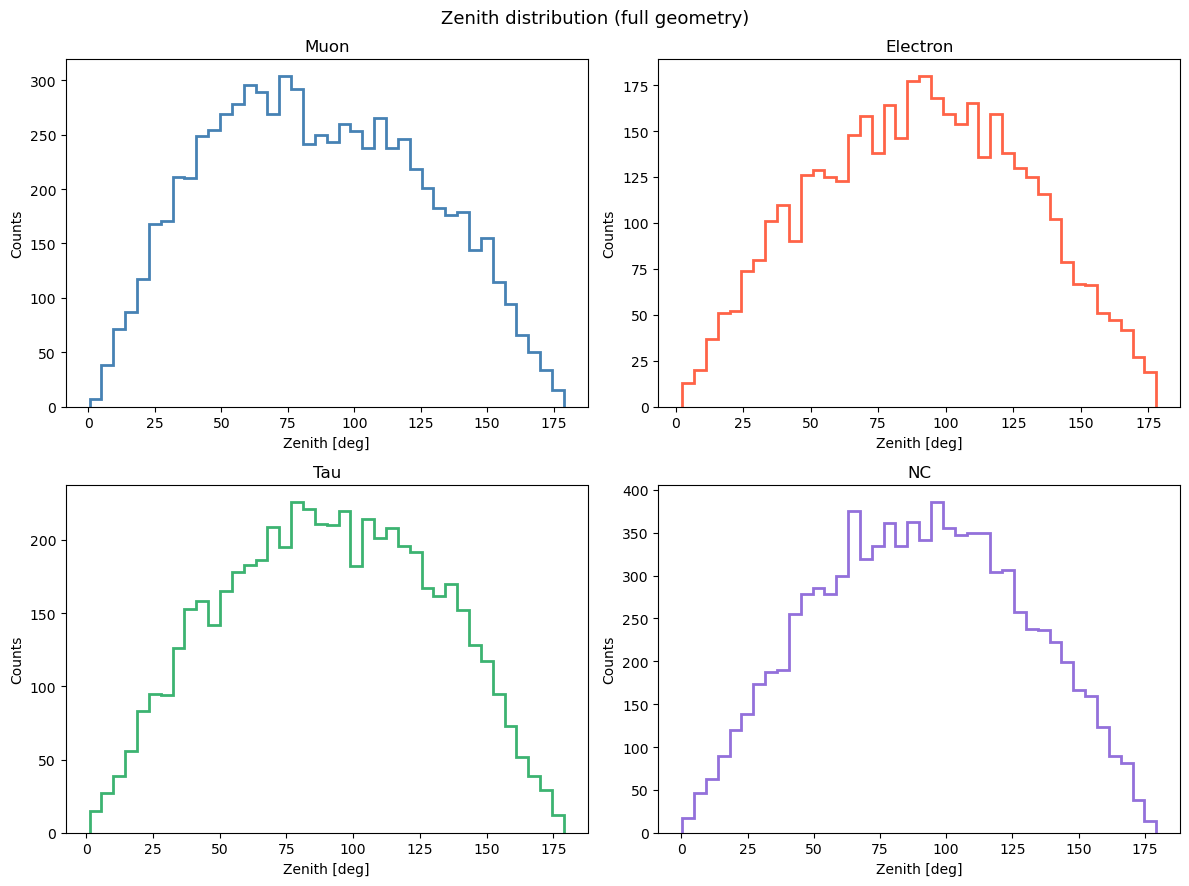

In [23]:
# Zenith
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
colors = {"Muon": "steelblue", "Electron": "tomato", "Tau": "mediumseagreen", "NC": "mediumpurple"}

for ax, (flavor, d) in zip(axes, event_data.items()):
    ax.hist(d["zenith"], bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Zenith [deg]")
    ax.set_ylabel("Counts")
    ax.set_title(flavor)

plt.suptitle("Zenith distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig("zenith_distribution_full_geometry.png", dpi=150)
plt.show()


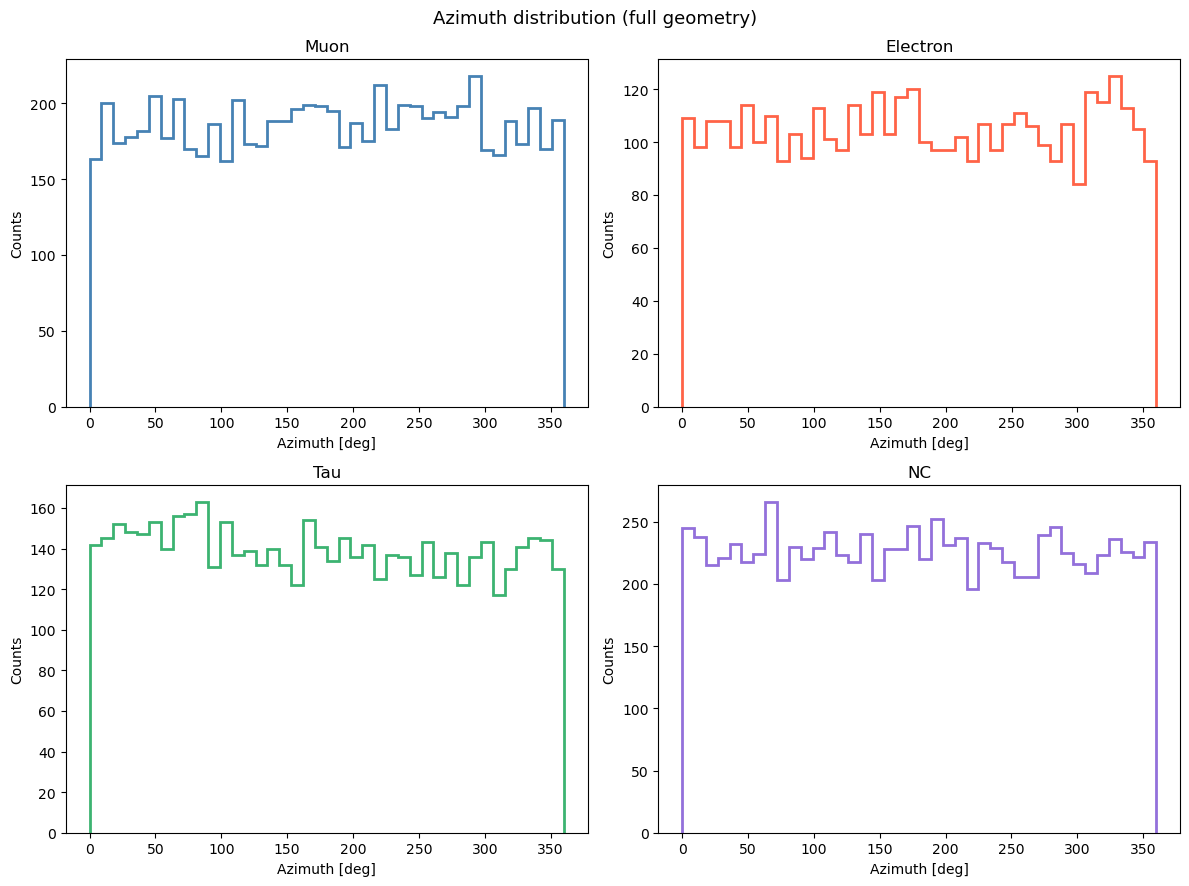

In [24]:
# Azimuth
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (flavor, d) in zip(axes, event_data.items()):
    ax.hist(d["azimuth"], bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Azimuth [deg]")
    ax.set_ylabel("Counts")
    ax.set_title(flavor)

plt.suptitle("Azimuth distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig("azimuth_distribution_full_geometry.png", dpi=150)
plt.show()


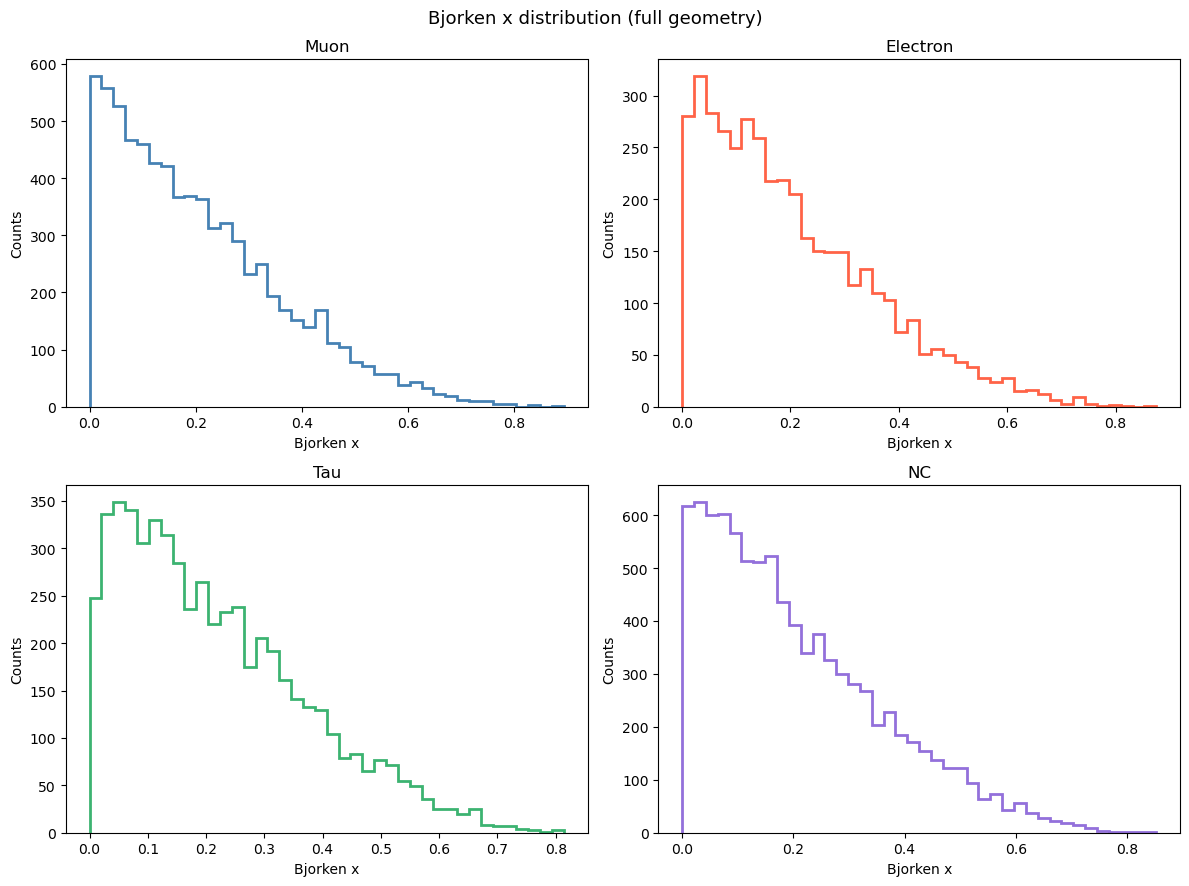

In [25]:
# Bjorken X
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (flavor, d) in zip(axes, event_data.items()):
    bx = d["bjorken_x"]
    bx = bx[~np.isnan(bx)]
    ax.hist(bx, bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Bjorken x")
    ax.set_ylabel("Counts")
    ax.set_title(flavor)

plt.suptitle("Bjorken x distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig("bjorken_x_distribution_full_geometry.png", dpi=150)
plt.show()


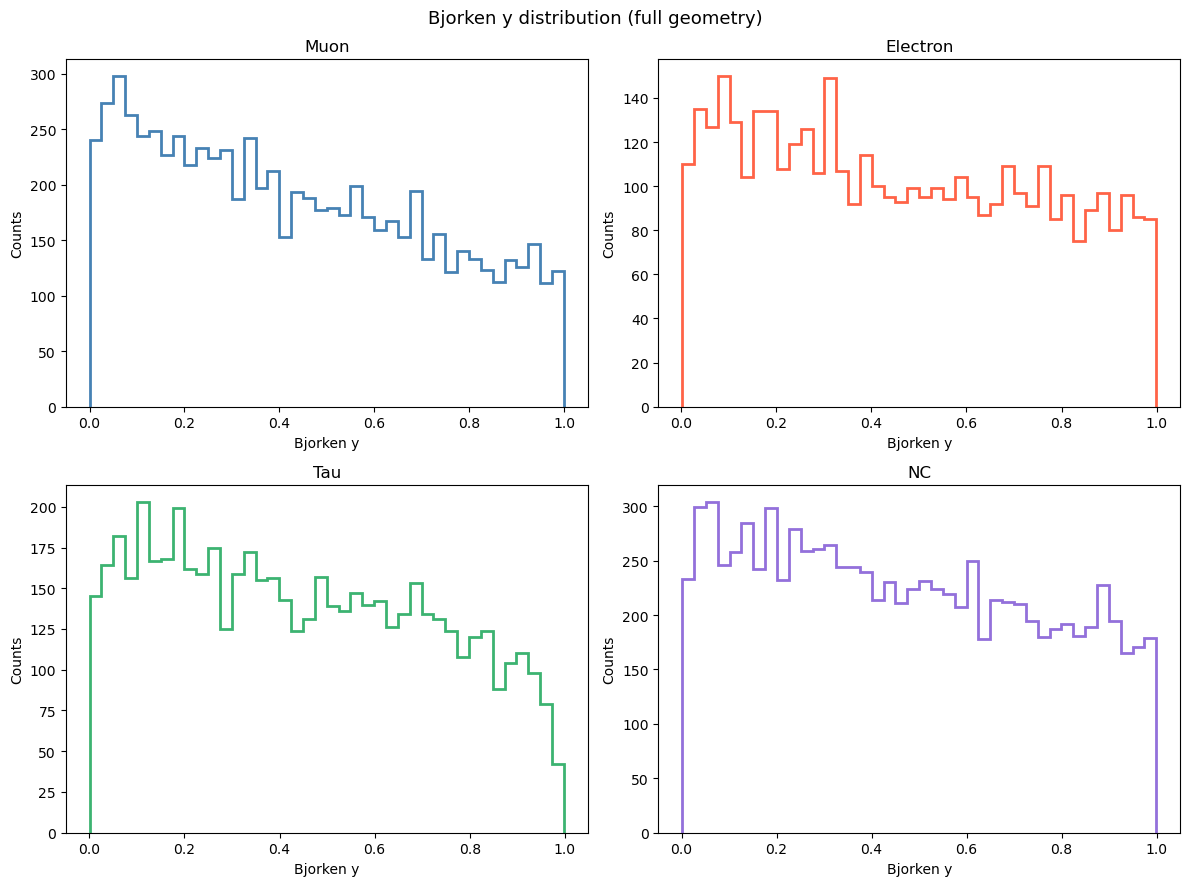

In [26]:
# Bjorken Y
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (flavor, d) in zip(axes, event_data.items()):
    by = d["bjorken_y"]
    by = by[~np.isnan(by)]
    ax.hist(by, bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Bjorken y")
    ax.set_ylabel("Counts")
    ax.set_title(flavor)

plt.suptitle("Bjorken y distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig("bjorken_y_distribution_full_geometry.png", dpi=150)
plt.show()


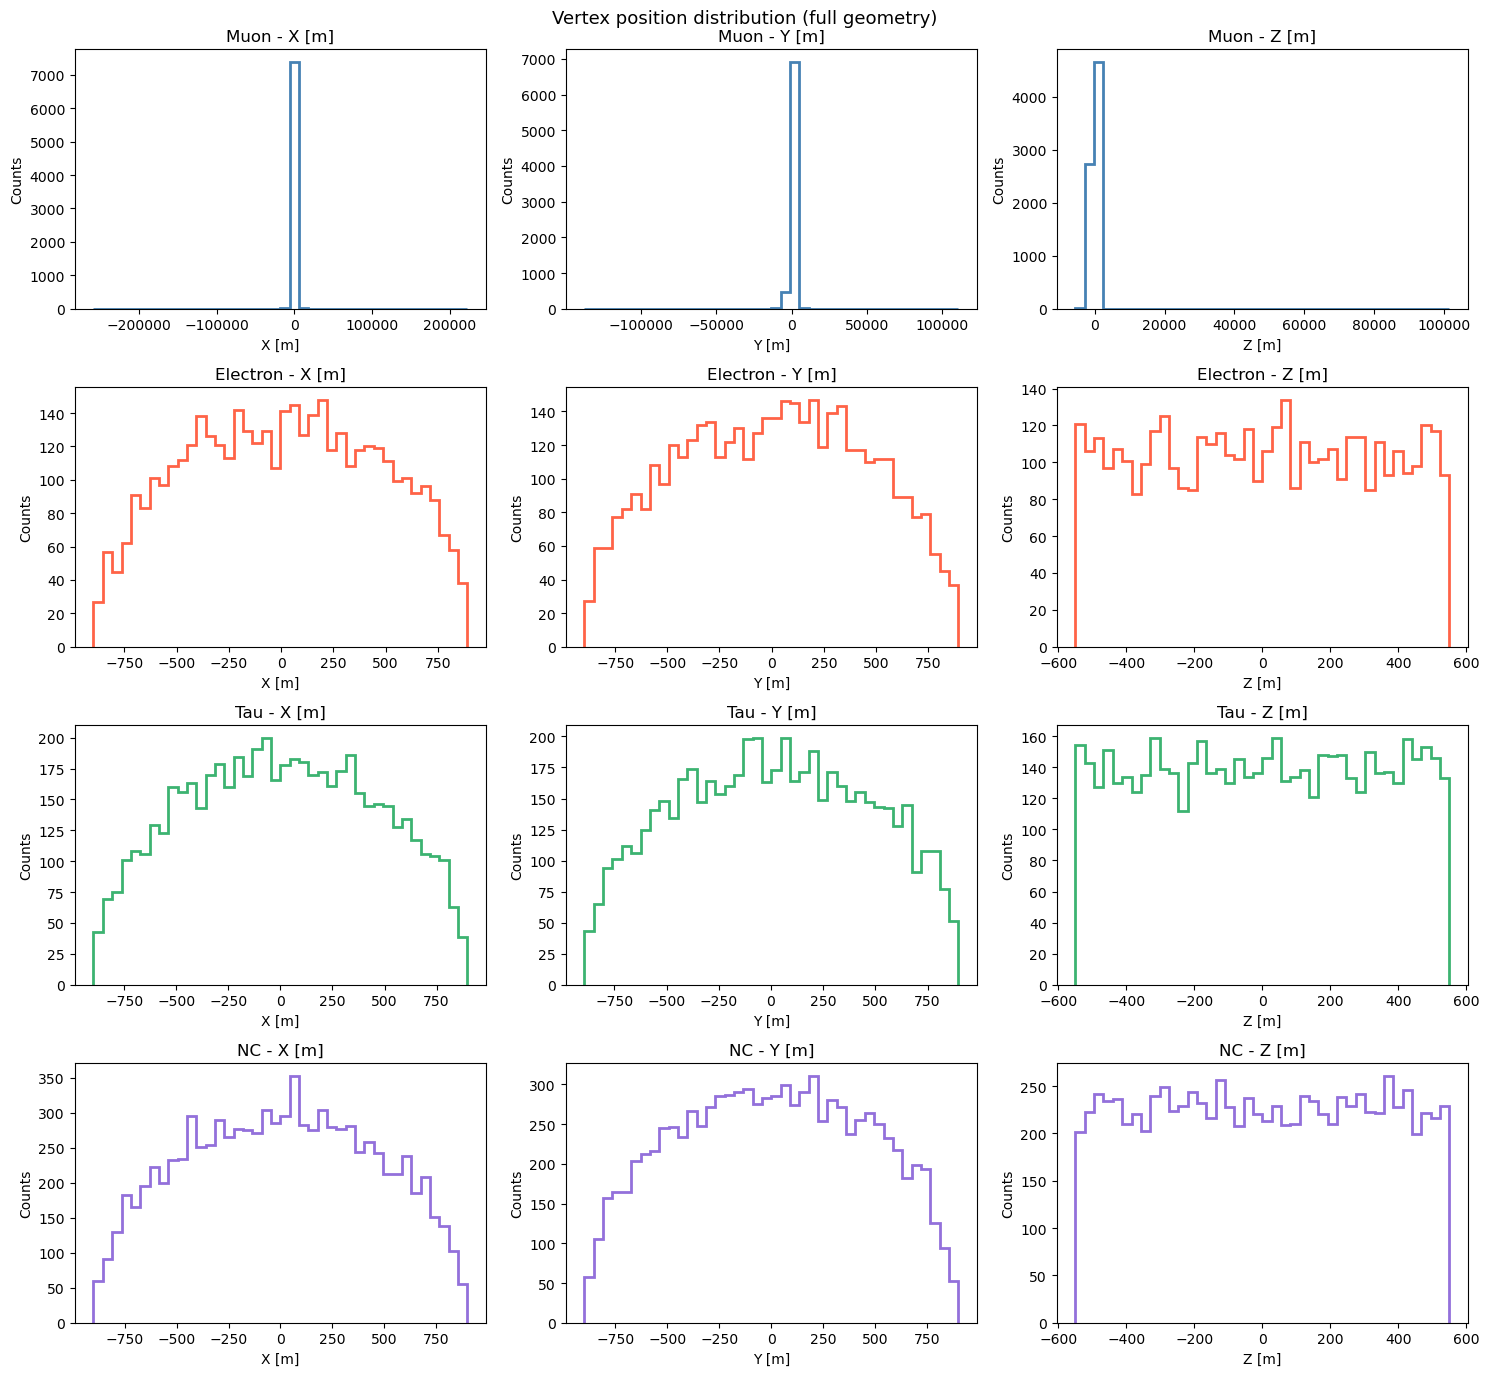

In [27]:
# Position X, Y, Z
fig, axes = plt.subplots(4, 3, figsize=(15, 14))

for row, (flavor, d) in enumerate(event_data.items()):
    for col, (key, label) in enumerate([("pos_x", "X [m]"), ("pos_y", "Y [m]"), ("pos_z", "Z [m]")]):
        ax = axes[row, col]
        ax.hist(d[key], bins=40, color=colors[flavor], histtype="step", linewidth=2)
        ax.set_xlabel(label)
        ax.set_ylabel("Counts")
        ax.set_title(f"{flavor} - {label}")

plt.suptitle("Vertex position distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig("position_distribution_full_geometry.png", dpi=150)
plt.show()
